# Notebook 01 — Exploratory Data Analysis

Understanding the raw data before any preprocessing — class balance, text length, and label quality.

In [1]:
import pandas as pd
import numpy as np
DATASET_PATH = "../data/raw/Emotion_classify_Data.csv"


## 1.1 Load the data

Confirm shape, dtypes, and null counts before touching anything.

In [2]:
df = pd.read_csv(DATASET_PATH)
df.info()
df.describe()
print(f'Dataset shape: {df.shape}')
print(f'Dataset types: {df.dtypes}')

<class 'pandas.DataFrame'>
RangeIndex: 5937 entries, 0 to 5936
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Comment  5937 non-null   str  
 1   Emotion  5937 non-null   str  
dtypes: str(2)
memory usage: 92.9 KB
Dataset shape: (5937, 2)
Dataset types: Comment    str
Emotion    str
dtype: object


**Result:** 5,937 rows, 2 string columns (`Comment`, `Emotion`), no nulls.

## 1.2 Class balance

Imbalance affects the choice of loss function and makes accuracy misleading as a sole metric.

In [3]:
df.value_counts(['Emotion'])

Emotion
anger      2000
joy        2000
fear       1937
Name: count, dtype: int64

**Result:** anger 2,000 · joy 2,000 · fear 1,937 — near-balanced

## 1.3 Text length distribution

Informs the max sequence length and whether truncation will lose meaningful content.

In [4]:
word_count = df['Comment'].apply(lambda x: len(str(x).split()))
word_count.describe()

count    5937.000000
mean       19.253495
std        11.070449
min         2.000000
25%        11.000000
50%        17.000000
75%        26.000000
max        64.000000
Name: Comment, dtype: float64

**Result:** Mean 19 words, median 17, max 64 — short texts. 75% of comments are under 26 words.

### 1.3a Histogram

Makes skew and outliers visible at a glance.

<Axes: >

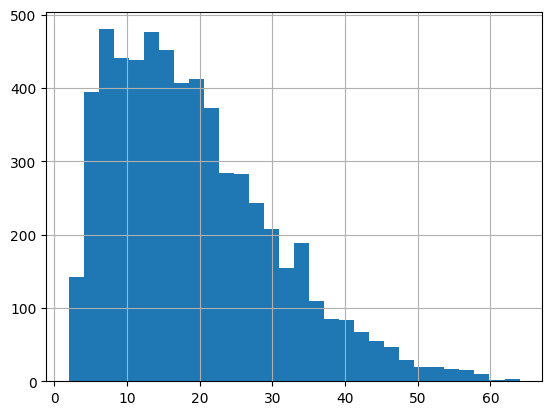

In [5]:
word_count.hist(bins=30)

**Result:** Right-skewed — the bulk of comments cluster under 30 words with a long tail toward 64.

## 1.4 Qualitative sample inspection

Manual read of 5 samples per class — checking for noise and whether labels match the text.

In [6]:
def random_sample(df, n=5):
    for emotion in df["Emotion"].unique():
        print(f"\n--- {emotion.upper()} ---")
        sample = df[df["Emotion"] == emotion].sample(n=n, random_state=42)
        print(sample[["Comment", "Emotion"]].to_string(index=False))

random_sample(df, n=5)


--- FEAR ---
                                                                                                                       Comment Emotion
                                                       im left feeling paranoid and like it keeps getting harder to feel happy    fear
i remember sitting in my family room in dallas watching the story unfold in new york so many years ago and feeling so helpless    fear
                                                i al feeling rather agitated and i am not totally sure where it is coming from    fear
                                                                                 i feel nervous but hes in control pretty soon    fear
                                    i feel really nervous about losing it i print the file out on to paper as a final security    fear

--- ANGER ---
                                                                                                                                                                 

**Result:** No URLs or encoding artifacts. Label noise present — one typo, two likely false labels, one ambiguous case across the three classes.

## 1.5 Missing values and duplicates

Duplicates can leak training examples into the validation set and inflate metrics.

In [7]:
print(f'is null: {df.isnull().sum()}')
print(f'duplicates: {df[df.duplicated(subset="Comment", keep=False)].sort_values("Comment")}')

is null: Comment    0
Emotion    0
dtype: int64
duplicates:                                                 Comment Emotion
2262   i feel like a tortured artist when i talk to her   anger
5870   i feel like a tortured artist when i talk to her    fear
2877  i feel pretty tortured because i work a job an...   anger
4869  i feel pretty tortured because i work a job an...    fear
986   i resorted to yesterday the post peak day of i...   anger
1930  i resorted to yesterday the post peak day of i...    fear


In [8]:
conflicts = (
    df.groupby("Comment")["Emotion"]
    .nunique()
    .loc[lambda s: s > 1]
    .index
)
df[df["Comment"].isin(conflicts)].sort_values("Comment")

,Comment,Emotion
2262,i feel like a tortured artist when i talk to her,anger
5870,i feel like a tortured artist when i talk to her,fear
2877,i feel pretty tortured because i work a job an...,anger
4869,i feel pretty tortured because i work a job an...,fear
986,i resorted to yesterday the post peak day of i...,anger
1930,i resorted to yesterday the post peak day of i...,fear


**Result:** 0 nulls. 6 duplicate rows — 3 pairs, all with identical comment text but different labels. Every single pair is labeled `anger` in one copy and `fear` in the other — never any other combination.

## 1.6 Summary and decisions

### Findings

| Check | Result |
|---|---|
| Shape | 5,937 rows × 2 columns |
| Missing values | None |
| Duplicates | 3 pairs (6 rows) — all anger/fear conflicts |
| Class balance | anger 2,000 · joy 2,000 · fear 1,937 — near-balanced |
| Text length | Mean 19 words, max 64, 75th pct at 26 |
| Label noise | Present |

### Label issues observed

- `"i al feeling rather agitated"` — typo ("al" → "am"), labeled `fear` but semantically closer to `anger`
- `"i am for the first time this year feeling the cold"` — labeled `anger`, no emotional signal
- `"i feel there are dangerous games or activities"` — labeled `anger`, reads as apprehension

### Duplicate pattern

All 3 duplicate pairs share the same comment text but carry conflicting labels — and in every case the conflict is specifically `anger` vs `fear`, never any other pairing. This is not random noise. It suggests these two classes are genuinely hard to distinguish from text alone — annotators disagreed on the same sentences, and always in this specific direction. This is worth flagging: if the confusion matrix in Step 7 shows the model mixing up `anger` and `fear` more than any other pair, the seed of that confusion is already visible here.

### Decision

Duplicate rows dropped , discard the conflicting label. Label noise otherwise accepted as-is. The dataset is large and near-balanced enough for the model to learn through it.
